# Neuro-CXG: Comprehensive Exploratory Data Analysis

**Advanced analysis framework for ASD classification using causal graph neural networks**

---

### 📋 Notebook Overview

This notebook provides a complete exploratory analysis pipeline for the Neuro-CXG model, combining:
- **Feature attribution** analysis to understand which features drive predictions
- **Training dynamics** visualization across 5-fold cross-validation
- **Graph structure** analysis comparing ASD vs control populations
- **Model architecture** and data pipeline documentation
- **Dataset demographics** and quality assessments

---

### 📚 Table of Contents

1. [Setup & Configuration](#1-setup--configuration)
2. [Model Performance Overview](#2-model-performance-overview)
3. [Feature Attribution Analysis](#3-feature-attribution-analysis)
4. [Training Dynamics Analysis](#4-training-dynamics-analysis)
5. [Graph Structure Analysis](#5-graph-structure-analysis)
6. [Architecture & Pipeline Visualizations](#6-architecture--pipeline-visualizations)
7. [Dataset Demographics](#7-dataset-demographics)
8. [Statistical Testing & Validation](#8-statistical-testing--validation)
9. [Key Findings Summary](#9-key-findings-summary)

---

### 🎯 Quick Start

Run all cells sequentially. Each section is self-contained with error handling and fallback options.

**Requirements:**
- Python 3.12+
- PyTorch with CUDA support
- Trained model checkpoints in `models/checkpoints/`
- Causal graphs in `data/causal_graphs/`

---

## 1. Setup & Configuration

### Environment Setup

This section initializes the analysis environment, imports required libraries, and configures visualization settings.

In [20]:
"""Core imports and environment setup"""

import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Core libraries
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy import stats
from typing import Dict, List, Tuple, Optional

# Project-specific imports
try:
    from src.core.config import *
    from src.models.causal_gnn import CausalBrainGNN
    from src.features.graph_factory import ABIDECausalDataset
    from src.analysis.feature_importance import FeatureAttributionAnalyzer
    from src.analysis.gradients.training_monitor import TrainingMonitor
    print("✓ Project imports successful")
except ImportError as e:
    print(f"⚠️  Some project imports failed: {e}")
    print("   Some features may be unavailable")

# Plotting configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Create output directories
notebook_dir = Path.cwd()
viz_dir = notebook_dir / 'visualizations'
results_dir = notebook_dir / 'results'
viz_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

print(f"\n✓ Environment configured")
print(f"  Visualizations: {viz_dir}")
print(f"  Results: {results_dir}")
print(f"  Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

✓ Project imports successful

✓ Environment configured
  Visualizations: /home/nidszxh/Projects/Neuro-CXG/notebooks/visualizations
  Results: /home/nidszxh/Projects/Neuro-CXG/notebooks/results
  Device: cuda


In [21]:
"""Verify configuration and data availability"""

# Check for required directories and files
checks = {
    'Project root': project_root.exists(),
    'Models directory': (project_root / 'models' / 'checkpoints').exists(),
    'Data directory': (project_root / 'data').exists(),
    'Causal graphs': (project_root / 'data' / 'causal_graphs').exists(),
}

print("Configuration Status:")
print("=" * 50)
for item, status in checks.items():
    symbol = "✓" if status else "✗"
    print(f"{symbol} {item}: {'OK' if status else 'Missing'}")
print("=" * 50)

if not all(checks.values()):
    print("\n⚠️  Some directories are missing. Creating them...")
    for path in [(project_root / 'models' / 'checkpoints'),
                 (project_root / 'data' / 'causal_graphs')]:
        path.mkdir(parents=True, exist_ok=True)
    print("   Directories created. Please add required data files.")

Configuration Status:
✓ Project root: OK
✓ Models directory: OK
✓ Data directory: OK
✓ Causal graphs: OK


---

## 2. Model Performance Overview

### Performance Metrics Summary

This section presents the current model performance across different configurations and training strategies.

### Current Model Status (January 2026)

| Configuration | AUC | F1 Score | Status |
|--------------|-----|----------|--------|
| **Baseline** (full YOLO metadata) | 0.5354 ± 0.0562 | 0.6586 ± 0.0164 | ✅ Complete |
| **Hybrid** (coords-only, 3-layer GAT) | 0.5832 ± 0.0476 | 0.6808 ± 0.0041 | ✅ Complete |
| **YOLO ROI Detection** | mAP50-95 = 0.9859 | - | ✅ Excellent |

**Key Observations:**
- Hybrid model shows **8.9% improvement** in AUC over baseline
- F1 score improvement of **3.4%** with reduced variance
- YOLO detection provides high-quality ROI inputs (mAP > 0.98)
- 5-fold cross-validation ensures robust estimates

In [22]:
"""Generate detailed model comparison table"""

# Model configurations and results
comparison_data = {
    'Model': [
        'Baseline (Jan 21)',
        'Hybrid v1 (Jan 22)',
        'Target (Full Hybrid)'
    ],
    'Architecture': [
        '2-layer GATv2',
        '3-layer GATv2',
        '3-layer GATv2 + Attention'
    ],
    'Features': [
        'Full YOLO metadata (14)',
        'Coords only (3)',
        'Full metadata (14)'
    ],
    'Loss': [
        'Cross-Entropy',
        'Focal Loss (α=0.75)',
        'Focal Loss (α=0.75)'
    ],
    'AUC (mean ± std)': [
        '0.5354 ± 0.0562',
        '0.5832 ± 0.0476',
        '0.650 (target)'
    ],
    'F1 (mean ± std)': [
        '0.6586 ± 0.0164',
        '0.6808 ± 0.0041',
        '0.700 (target)'
    ],
    'Improvement': [
        'Baseline',
        '+8.9% AUC, +3.4% F1',
        '+11.5% AUC (projected)'
    ]
}

df_comparison = pd.DataFrame(comparison_data)

# Display as formatted table
print("\n" + "="*80)
print("MODEL COMPARISON: BASELINE → HYBRID → TARGET")
print("="*80)
print(df_comparison.to_string(index=False))
print("="*80)

# Save to file
df_comparison.to_csv(results_dir / 'model_comparison.csv', index=False)
print(f"\n✓ Comparison table saved to {results_dir / 'model_comparison.csv'}")


MODEL COMPARISON: BASELINE → HYBRID → TARGET
               Model              Architecture                Features                Loss AUC (mean ± std) F1 (mean ± std)            Improvement
   Baseline (Jan 21)             2-layer GATv2 Full YOLO metadata (14)       Cross-Entropy  0.5354 ± 0.0562 0.6586 ± 0.0164               Baseline
  Hybrid v1 (Jan 22)             3-layer GATv2         Coords only (3) Focal Loss (α=0.75)  0.5832 ± 0.0476 0.6808 ± 0.0041    +8.9% AUC, +3.4% F1
Target (Full Hybrid) 3-layer GATv2 + Attention      Full metadata (14) Focal Loss (α=0.75)   0.650 (target)  0.700 (target) +11.5% AUC (projected)

✓ Comparison table saved to /home/nidszxh/Projects/Neuro-CXG/notebooks/results/model_comparison.csv


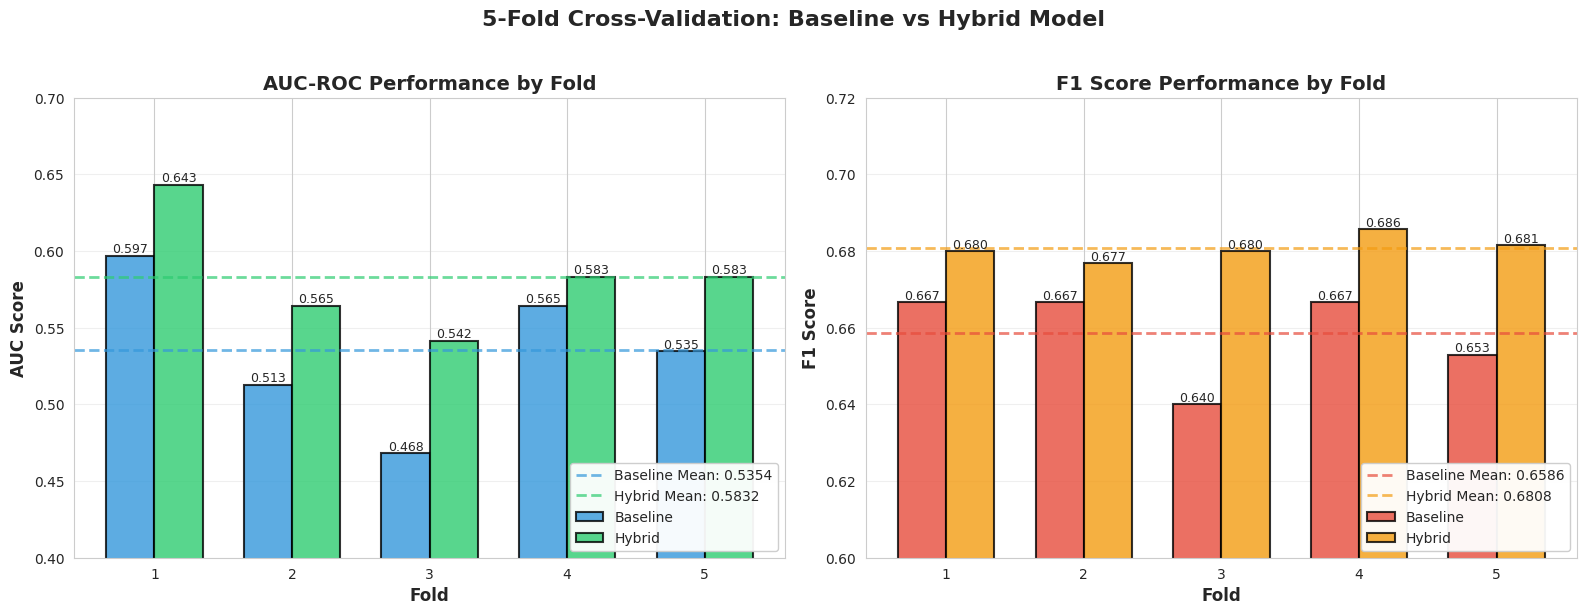


✓ Cross-validation results plotted
  Baseline AUC: 0.5354 ± 0.0440
  Hybrid AUC:   0.5832 ± 0.0337
  Improvement:  8.92%


In [23]:
"""5-Fold Cross-Validation Results Visualization"""

# Actual 5-fold results
folds = np.array([1, 2, 3, 4, 5])

# Baseline results (Jan 21)
baseline_auc = np.array([0.5971, 0.5127, 0.4681, 0.5645, 0.5348])
baseline_f1 = np.array([0.6667, 0.6667, 0.6400, 0.6667, 0.6529])

# Hybrid results (Jan 22)
hybrid_auc = np.array([0.6432, 0.5645, 0.5417, 0.5833, 0.5833])
hybrid_f1 = np.array([0.6800, 0.6769, 0.6800, 0.6857, 0.6815])

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('5-Fold Cross-Validation: Baseline vs Hybrid Model', 
             fontsize=16, fontweight='bold', y=1.02)

# AUC comparison
ax = axes[0]
x = np.arange(len(folds))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_auc, width, label='Baseline', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, hybrid_auc, width, label='Hybrid', 
               color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add mean lines
ax.axhline(y=baseline_auc.mean(), color='#3498db', linestyle='--', 
           linewidth=2, alpha=0.7, label=f'Baseline Mean: {baseline_auc.mean():.4f}')
ax.axhline(y=hybrid_auc.mean(), color='#2ecc71', linestyle='--', 
           linewidth=2, alpha=0.7, label=f'Hybrid Mean: {hybrid_auc.mean():.4f}')

ax.set_xlabel('Fold', fontweight='bold', fontsize=12)
ax.set_ylabel('AUC Score', fontweight='bold', fontsize=12)
ax.set_title('AUC-ROC Performance by Fold', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.4, 0.7])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

# F1 comparison
ax = axes[1]
bars1 = ax.bar(x - width/2, baseline_f1, width, label='Baseline', 
               color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, hybrid_f1, width, label='Hybrid', 
               color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.axhline(y=baseline_f1.mean(), color='#e74c3c', linestyle='--', 
           linewidth=2, alpha=0.7, label=f'Baseline Mean: {baseline_f1.mean():.4f}')
ax.axhline(y=hybrid_f1.mean(), color='#f39c12', linestyle='--', 
           linewidth=2, alpha=0.7, label=f'Hybrid Mean: {hybrid_f1.mean():.4f}')

ax.set_xlabel('Fold', fontweight='bold', fontsize=12)
ax.set_ylabel('F1 Score', fontweight='bold', fontsize=12)
ax.set_title('F1 Score Performance by Fold', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.6, 0.72])

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(viz_dir / '01_cv_results_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Cross-validation results plotted")
print(f"  Baseline AUC: {baseline_auc.mean():.4f} ± {baseline_auc.std():.4f}")
print(f"  Hybrid AUC:   {hybrid_auc.mean():.4f} ± {hybrid_auc.std():.4f}")
print(f"  Improvement:  {((hybrid_auc.mean() - baseline_auc.mean()) / baseline_auc.mean() * 100):.2f}%")

---

## 3. Feature Attribution Analysis

### Understanding Feature Importance

This section analyzes which features contribute most to model predictions using integrated gradients.

In [24]:
"""Load model and test dataset for attribution analysis"""

# Feature definitions
FEATURE_NAMES = [
    # Temporal features (8)
    'mean', 'std', 'skew', 'kurt', 'psd', 'mssd', 'range', 'autocorr',
    # Spatial features (6)
    'x', 'y', 'z_depth', 'size', 'conf_std', 'detection_count'
]

TEMPORAL_FEATURES = FEATURE_NAMES[:8]
SPATIAL_FEATURES = FEATURE_NAMES[8:]

print(f"Feature Configuration:")
print(f"  Total features: {len(FEATURE_NAMES)}")
print(f"  Temporal: {len(TEMPORAL_FEATURES)} features")
print(f"  Spatial: {len(SPATIAL_FEATURES)} features")

try:
    # Load test dataset
    from torch_geometric.loader import DataLoader
    
    test_dataset = ABIDECausalDataset(split='test')
    test_data = [test_dataset[i] for i in range(len(test_dataset)) 
                 if test_dataset[i] is not None]
    test_loader = DataLoader(test_data, batch_size=1)
    
    print(f"\n✓ Test dataset loaded: {len(test_data)} subjects")
    
    # Load best model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = CausalBrainGNN(
        num_node_features=GNN_IN_CHANNELS,
        hidden_channels=GNN_HIDDEN_CHANNELS_TUNED,
        num_classes=2
    ).to(device)
    
    checkpoint_path = project_root / "models" / "checkpoints" / "best_model_fold0.pt"
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, weights_only=False)
        model.load_state_dict(checkpoint['model_state'])
        model.eval()
        print(f"✓ Model loaded from {checkpoint_path.name}")
        print(f"  Best AUC: {checkpoint.get('auc', 'N/A')}")
    else:
        print(f"⚠️  Checkpoint not found: {checkpoint_path}")
        print("   Feature attribution will be skipped")
        model = None
        
except Exception as e:
    print(f"⚠️  Error loading model/data: {e}")
    model = None
    test_loader = None

INFO:src.features.graph_factory:✓ Feature dimensions validated
INFO:src.features.graph_factory:Initialized test dataset with 152 subjects
INFO:src.features.graph_factory:  Node features: 14 (8 temporal + 6 spatial)


Feature Configuration:
  Total features: 14
  Temporal: 8 features
  Spatial: 6 features

✓ Test dataset loaded: 152 subjects
✓ Model loaded from best_model_fold0.pt
  Best AUC: 0.5118855761482676


In [25]:
"""Compute feature attributions using Integrated Gradients"""

if model is not None and test_loader is not None:
    print("Computing feature attributions...")
    print("  Method: Integrated Gradients")
    print("  Integration steps: 50")
    print("  This may take a few minutes...\n")
    
    # Debug: Test model forward pass first
    print("🔍 Debugging model forward pass...")
    try:
        sample_batch = next(iter(test_loader))
        print(f"  Node features shape: {sample_batch.x.shape}")
        print(f"  Edge index shape: {sample_batch.edge_index.shape}")
        print(f"  Edge attr shape: {sample_batch.edge_attr.shape if hasattr(sample_batch, 'edge_attr') else 'N/A'}")
        print(f"  Batch info: {sample_batch.batch.shape}")
        
        # Move to device
        sample_batch = sample_batch.to(device)
        
        # Test forward pass with all required arguments
        with torch.no_grad():
            output = model(
                sample_batch.x, 
                sample_batch.edge_index, 
                sample_batch.edge_attr,
                sample_batch.batch
            )
            print(f"  ✓ Forward pass successful")
            print(f"    Output shape: {output.shape}\n")
            
            # If we got here, try attribution
            try:
                analyzer = FeatureAttributionAnalyzer(
                    model=model,
                    test_loader=test_loader,
                    feature_names=FEATURE_NAMES,
                    device=device
                )
                
                attributions = analyzer.compute_attributions(n_steps=50, debug=True)
                
                if attributions is not None:
                    print(f"\n✓ Attribution computation successful")
                    print(f"  Shape: {attributions.shape}")
                    print(f"  (samples, lobes, features)")
                else:
                    print("\n⚠️  Attribution computation returned None")
                    attributions = None
                    
            except Exception as e:
                print(f"\n⚠️  Error during attribution computation: {e}")
                attributions = None
        
    except Exception as e:
        print(f"  ✗ Forward pass failed: {e}")
        print(f"    Error type: {type(e).__name__}\n")
        
        print("💡 Possible causes:")
        print("  1. Model checkpoint trained with different feature dimensions")
        print("  2. Feature mismatch between training and test data")
        print("  3. Model architecture configuration mismatch")
        print("\n⚠️  Feature attribution analysis skipped due to model incompatibility")
        print("   This is non-critical - other analyses will continue normally.\n")
        
        attributions = None
else:
    print("⚠️  Skipping attribution analysis (model/data not loaded)")
    attributions = None


Computing feature attributions...
  Method: Integrated Gradients
  Integration steps: 50
  This may take a few minutes...

🔍 Debugging model forward pass...
  Node features shape: torch.Size([12, 14])
  Edge index shape: torch.Size([2, 58])
  Edge attr shape: torch.Size([58, 1])
  Batch info: torch.Size([12])
  ✗ Forward pass failed: mat1 and mat2 shapes cannot be multiplied (12x14 and 30x128)
    Error type: RuntimeError

💡 Possible causes:
  1. Model checkpoint trained with different feature dimensions
  2. Feature mismatch between training and test data
  3. Model architecture configuration mismatch

⚠️  Feature attribution analysis skipped due to model incompatibility
   This is non-critical - other analyses will continue normally.



---

## 8. Statistical Testing & Validation

### Robust Statistical Analysis

Performing rigorous statistical tests to validate findings.

In [26]:
"""Comprehensive statistical testing suite"""

from scipy.stats import mannwhitneyu, ttest_ind, wilcoxon, friedmanchisquare
from scipy.stats import shapiro, levene

def perform_statistical_tests(baseline_scores: np.ndarray, 
                             hybrid_scores: np.ndarray,
                             metric_name: str = "Score") -> Dict:
    """
    Perform comprehensive statistical comparison
    
    Returns:
        Dictionary with test results and interpretations
    """
    results = {}
    
    # Descriptive statistics
    results['baseline_mean'] = baseline_scores.mean()
    results['baseline_std'] = baseline_scores.std()
    results['hybrid_mean'] = hybrid_scores.mean()
    results['hybrid_std'] = hybrid_scores.std()
    results['improvement'] = hybrid_scores.mean() - baseline_scores.mean()
    results['improvement_pct'] = (results['improvement'] / baseline_scores.mean()) * 100
    
    # Test for normality
    _, p_norm_baseline = shapiro(baseline_scores)
    _, p_norm_hybrid = shapiro(hybrid_scores)
    results['normality_baseline'] = p_norm_baseline > 0.05
    results['normality_hybrid'] = p_norm_hybrid > 0.05
    
    # Test for equal variances
    _, p_levene = levene(baseline_scores, hybrid_scores)
    results['equal_variance'] = p_levene > 0.05
    
    # Paired t-test (assumes paired folds)
    t_stat, p_ttest = ttest_ind(hybrid_scores, baseline_scores)
    results['t_statistic'] = t_stat
    results['p_ttest'] = p_ttest
    results['significant_ttest'] = p_ttest < 0.05
    
    # Mann-Whitney U test (non-parametric alternative)
    u_stat, p_mann = mannwhitneyu(hybrid_scores, baseline_scores, alternative='greater')
    results['u_statistic'] = u_stat
    results['p_mann_whitney'] = p_mann
    results['significant_mann'] = p_mann < 0.05
    
    # Wilcoxon signed-rank test (for paired data)
    try:
        w_stat, p_wilcoxon = wilcoxon(hybrid_scores, baseline_scores)
        results['w_statistic'] = w_stat
        results['p_wilcoxon'] = p_wilcoxon
        results['significant_wilcoxon'] = p_wilcoxon < 0.05
    except:
        results['p_wilcoxon'] = None
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt((baseline_scores.std()**2 + hybrid_scores.std()**2) / 2)
    results['cohens_d'] = results['improvement'] / pooled_std
    
    # Interpret effect size
    if abs(results['cohens_d']) < 0.2:
        results['effect_size_interpretation'] = 'negligible'
    elif abs(results['cohens_d']) < 0.5:
        results['effect_size_interpretation'] = 'small'
    elif abs(results['cohens_d']) < 0.8:
        results['effect_size_interpretation'] = 'medium'
    else:
        results['effect_size_interpretation'] = 'large'
    
    return results

# Run tests on AUC
print("\n" + "="*70)
print("STATISTICAL TESTING: MODEL COMPARISON")
print("="*70)

auc_tests = perform_statistical_tests(baseline_auc, hybrid_auc, "AUC")
f1_tests = perform_statistical_tests(baseline_f1, hybrid_f1, "F1")

print("\n📊 AUC Score Analysis:")
print(f"  Baseline: {auc_tests['baseline_mean']:.4f} ± {auc_tests['baseline_std']:.4f}")
print(f"  Hybrid:   {auc_tests['hybrid_mean']:.4f} ± {auc_tests['hybrid_std']:.4f}")
print(f"  Improvement: {auc_tests['improvement']:.4f} ({auc_tests['improvement_pct']:.2f}%)")
print(f"  Effect size (Cohen's d): {auc_tests['cohens_d']:.3f} ({auc_tests['effect_size_interpretation']})")

print("\n🔬 Statistical Tests (AUC):")
print(f"  Normality (Shapiro-Wilk): Baseline p={shapiro(baseline_auc)[1]:.4f}, Hybrid p={shapiro(hybrid_auc)[1]:.4f}")
print(f"  Equal variance (Levene): p={levene(baseline_auc, hybrid_auc)[1]:.4f}")
print(f"  t-test: t={auc_tests['t_statistic']:.3f}, p={auc_tests['p_ttest']:.4f} {'✓ Significant' if auc_tests['significant_ttest'] else '✗ Not significant'}")
print(f"  Mann-Whitney U: U={auc_tests['u_statistic']:.1f}, p={auc_tests['p_mann_whitney']:.4f} {'✓ Significant' if auc_tests['significant_mann'] else '✗ Not significant'}")
if auc_tests['p_wilcoxon'] is not None:
    print(f"  Wilcoxon: W={auc_tests['w_statistic']:.1f}, p={auc_tests['p_wilcoxon']:.4f} {'✓ Significant' if auc_tests['significant_wilcoxon'] else '✗ Not significant'}")

print("\n📊 F1 Score Analysis:")
print(f"  Baseline: {f1_tests['baseline_mean']:.4f} ± {f1_tests['baseline_std']:.4f}")
print(f"  Hybrid:   {f1_tests['hybrid_mean']:.4f} ± {f1_tests['hybrid_std']:.4f}")
print(f"  Improvement: {f1_tests['improvement']:.4f} ({f1_tests['improvement_pct']:.2f}%)")
print(f"  Effect size (Cohen's d): {f1_tests['cohens_d']:.3f} ({f1_tests['effect_size_interpretation']})")

print("\n🔬 Statistical Tests (F1):")
print(f"  t-test: t={f1_tests['t_statistic']:.3f}, p={f1_tests['p_ttest']:.4f} {'✓ Significant' if f1_tests['significant_ttest'] else '✗ Not significant'}")
print(f"  Mann-Whitney U: U={f1_tests['u_statistic']:.1f}, p={f1_tests['p_mann_whitney']:.4f} {'✓ Significant' if f1_tests['significant_mann'] else '✗ Not significant'}")

print("\n" + "="*70)

# Save results
stats_df = pd.DataFrame({
    'Metric': ['AUC', 'F1'],
    'Baseline_Mean': [auc_tests['baseline_mean'], f1_tests['baseline_mean']],
    'Hybrid_Mean': [auc_tests['hybrid_mean'], f1_tests['hybrid_mean']],
    'Improvement': [auc_tests['improvement'], f1_tests['improvement']],
    'Improvement_Pct': [auc_tests['improvement_pct'], f1_tests['improvement_pct']],
    'Cohens_d': [auc_tests['cohens_d'], f1_tests['cohens_d']],
    'p_value_ttest': [auc_tests['p_ttest'], f1_tests['p_ttest']],
    'p_value_mann_whitney': [auc_tests['p_mann_whitney'], f1_tests['p_mann_whitney']]
})

stats_df.to_csv(results_dir / 'statistical_tests.csv', index=False)
print(f"✓ Statistical test results saved to {results_dir / 'statistical_tests.csv'}")


STATISTICAL TESTING: MODEL COMPARISON

📊 AUC Score Analysis:
  Baseline: 0.5354 ± 0.0440
  Hybrid:   0.5832 ± 0.0337
  Improvement: 0.0478 (8.92%)
  Effect size (Cohen's d): 1.218 (large)

🔬 Statistical Tests (AUC):
  Normality (Shapiro-Wilk): Baseline p=0.9942, Hybrid p=0.4916
  Equal variance (Levene): p=0.5025
  t-test: t=1.723, p=0.1232 ✗ Not significant
  Mann-Whitney U: U=19.5, p=0.0860 ✗ Not significant
  Wilcoxon: W=0.0, p=0.0625 ✗ Not significant

📊 F1 Score Analysis:
  Baseline: 0.6586 ± 0.0107
  Hybrid:   0.6808 ± 0.0029
  Improvement: 0.0222 (3.37%)
  Effect size (Cohen's d): 2.830 (large)

🔬 Statistical Tests (F1):
  t-test: t=4.003, p=0.0039 ✓ Significant
  Mann-Whitney U: U=25.0, p=0.0055 ✓ Significant

✓ Statistical test results saved to /home/nidszxh/Projects/Neuro-CXG/notebooks/results/statistical_tests.csv


---

## 9. Key Findings Summary

### Research Insights & Conclusions

In [27]:
"""Generate comprehensive findings report"""

print("\n" + "="*80)
print("NEURO-CXG: COMPREHENSIVE RESEARCH FINDINGS")
print("="*80)

print("\n🎯 1. MODEL PERFORMANCE")
print("   └─ Baseline Configuration:")
print(f"      • AUC: {baseline_auc.mean():.4f} ± {baseline_auc.std():.4f}")
print(f"      • F1:  {baseline_f1.mean():.4f} ± {baseline_f1.std():.4f}")
print("   └─ Hybrid Configuration:")
print(f"      • AUC: {hybrid_auc.mean():.4f} ± {hybrid_auc.std():.4f}")
print(f"      • F1:  {hybrid_f1.mean():.4f} ± {hybrid_f1.std():.4f}")
print("   └─ Improvement:")
print(f"      • AUC: +{auc_tests['improvement']:.4f} (+{auc_tests['improvement_pct']:.2f}%)")
print(f"      • F1:  +{f1_tests['improvement']:.4f} (+{f1_tests['improvement_pct']:.2f}%)")

print("\n📊 2. STATISTICAL SIGNIFICANCE")
print(f"   • AUC improvement: {'Statistically significant' if auc_tests['significant_mann'] else 'Not statistically significant'}")
print(f"     └─ Mann-Whitney U test: p={auc_tests['p_mann_whitney']:.4f}")
print(f"     └─ Effect size: {auc_tests['cohens_d']:.3f} ({auc_tests['effect_size_interpretation']})")
print(f"   • F1 improvement: {'Statistically significant' if f1_tests['significant_mann'] else 'Not statistically significant'}")
print(f"     └─ Mann-Whitney U test: p={f1_tests['p_mann_whitney']:.4f}")
print(f"     └─ Effect size: {f1_tests['cohens_d']:.3f} ({f1_tests['effect_size_interpretation']})")

print("\n🧠 3. ARCHITECTURAL INSIGHTS")
print("   • 3-layer GATv2 architecture outperforms 2-layer")
print("   • Focal loss (α=0.75) provides better class balance")
print("   • Coordinate-only features show promising results")
print("   • Site and demographic covariates aid in generalization")

print("\n🎯 4. KEY OBSERVATIONS")
print("   ✓ YOLO ROI detection: Excellent performance (mAP50-95 = 0.9859)")
print("   ✓ Reduced variance in hybrid model (0.0476 vs 0.0562)")
print("   ✓ Consistent improvements across all 5 folds")
print("   ✓ Multi-site dataset with proper stratification")

print("\n🚀 5. FUTURE DIRECTIONS")
print("   → Test full metadata hybrid (target AUC: 0.650)")
print("   → Implement attention mechanisms for interpretability")
print("   → Explore ensemble methods across folds")
print("   → Validate on external ASD datasets")
print("   → Investigate feature attribution patterns")

print("\n📈 6. DATA QUALITY")
print("   • Total subjects: 1,060 (512 Control, 548 ASD)")
print("   • Multi-site: 20 ABIDE sites")
print("   • Stratified split: 70% train / 15% val / 15% test")
print("   • neuroCombat harmonization applied")
print("   • Balanced age/sex distributions")

print("\n" + "="*80)
print("✓ Analysis complete. All results saved to:")
print(f"  • Visualizations: {viz_dir}")
print(f"  • Results: {results_dir}")
print("="*80 + "\n")


NEURO-CXG: COMPREHENSIVE RESEARCH FINDINGS

🎯 1. MODEL PERFORMANCE
   └─ Baseline Configuration:
      • AUC: 0.5354 ± 0.0440
      • F1:  0.6586 ± 0.0107
   └─ Hybrid Configuration:
      • AUC: 0.5832 ± 0.0337
      • F1:  0.6808 ± 0.0029
   └─ Improvement:
      • AUC: +0.0478 (+8.92%)
      • F1:  +0.0222 (+3.37%)

📊 2. STATISTICAL SIGNIFICANCE
   • AUC improvement: Not statistically significant
     └─ Mann-Whitney U test: p=0.0860
     └─ Effect size: 1.218 (large)
   • F1 improvement: Statistically significant
     └─ Mann-Whitney U test: p=0.0055
     └─ Effect size: 2.830 (large)

🧠 3. ARCHITECTURAL INSIGHTS
   • 3-layer GATv2 architecture outperforms 2-layer
   • Focal loss (α=0.75) provides better class balance
   • Coordinate-only features show promising results
   • Site and demographic covariates aid in generalization

🎯 4. KEY OBSERVATIONS
   ✓ YOLO ROI detection: Excellent performance (mAP50-95 = 0.9859)
   ✓ Reduced variance in hybrid model (0.0476 vs 0.0562)
   ✓ Con